# IT Support Ticket Volume Forecasting

## Forecasting permintaan tiket IT Support menggunakan Time Series


### Business Objective
Tim IT Support perlu memperkirakan jumlah tiket yang akan masuk agar dapat:
- merencanakan kapasitas dan workload tim,
- mengantisipasi periode dengan lonjakan tiket,
- membantu penjadwalan support,
- memonitor risiko terhadap SLA.

### Target Forecast
**Jumlah tiket IT Support per hari (`daily ticket volume`)**

### Data
- SLA Support September - Desember 2024
- SLA Support Full Year 2025
- SLA Support Full Year 2026
- Periode 2026 bersifat **year-to-date**, sehingga bulan Oktober 2026 belum lengkap.

## Project Workflow

1. Business understanding
2. Load & combine data
3. Data quality check
4. Data cleaning
5. Exploratory Time Series Analysis
6. Train/validation split berbasis waktu
7. Baseline forecasting
8. Model comparison
9. Forecast future ticket volume
10. Business interpretation & recommendation

> **Catatan metodologi:** data Oktober 2026 belum lengkap. Untuk evaluasi model, September 2026 digunakan sebagai holdout month. Setelah model terbaik dipilih, model dilatih ulang menggunakan seluruh data aktual sampai tanggal terakhir yang tersedia.

## Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## 1. Upload Dataset

In [1]:
from google.colab import files

uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))

Saving SLA SUPPORT DECEMBER 2024.xlsx to SLA SUPPORT DECEMBER 2024.xlsx
Saving SLA SUPPORT NOVEMBER 2024.xlsx to SLA SUPPORT NOVEMBER 2024.xlsx
Saving SLA SUPPORT OCTOBER 2024.xlsx to SLA SUPPORT OCTOBER 2024.xlsx
Saving SLA SUPPORT SEPTEMBER 2024.xlsx to SLA SUPPORT SEPTEMBER 2024.xlsx
Uploaded files: ['SLA SUPPORT DECEMBER 2024.xlsx', 'SLA SUPPORT NOVEMBER 2024.xlsx', 'SLA SUPPORT OCTOBER 2024.xlsx', 'SLA SUPPORT SEPTEMBER 2024.xlsx']


In [5]:
import os

files_available = os.listdir("/content")
# Mengumpulkan semua file Excel yang mengandung tahun "2024"
files_2024 = [f for f in files_available if "2024" in f.upper() and f.lower().endswith(".xlsx")]
file_2025 = next((f for f in files_available if "2025" in f.upper() and f.lower().endswith(".xlsx")), None)
file_2026 = next((f for f in files_available if "2026" in f.upper() and f.lower().endswith(".xlsx")), None)

print("File-file 2024 ditemukan:", files_2024)
print("File 2025 ditemukan:", file_2025)
print("File 2026 ditemukan:", file_2026)

if not files_2024 or file_2025 is None or file_2026 is None:
    raise FileNotFoundError("Pastikan file Excel 2024 (September-Desember), 2025, dan 2026 sudah lengkap di-upload.")

File-file 2024 ditemukan: ['SLA SUPPORT DECEMBER 2024.xlsx', 'SLA SUPPORT SEPTEMBER 2024.xlsx', 'SLA SUPPORT OCTOBER 2024.xlsx', 'SLA SUPPORT NOVEMBER 2024.xlsx']
File 2025 ditemukan: SLA SUPPORT FULL YEAR 2025.xlsx
File 2026 ditemukan: SLA SUPPORT FULL YEAR 2026 (2).xlsx


In [6]:
# Membaca seluruh file 2024 dan menggabungkannya menjadi satu DataFrame
list_df_2024 = []
for file in files_2024:
    temp_df = pd.read_excel(file, engine="calamine")
    list_df_2024.append(temp_df)

df_2024 = pd.concat(list_df_2024, ignore_index=True)
df_2025 = pd.read_excel(file_2025, engine="calamine")
df_2026 = pd.read_excel(file_2026, engine="calamine")

print("2024 shape (gabungan September-Desember):", df_2024.shape)
print("2025 shape:", df_2025.shape)
print("2026 shape:", df_2026.shape)

2024 shape (gabungan September-Desember): (1586, 14)
2025 shape: (4253, 14)
2026 shape: (2433, 14)


## 2. Combine Dataset & Data Quality Check

In [9]:
# Menggabungkan seluruh data dari tahun 2024, 2025, dan 2026
df = pd.concat(
    [df_2024.assign(source_year=2024),
     df_2025.assign(source_year=2025),
     df_2026.assign(source_year=2026)],
    ignore_index=True
)

print("Combined shape (2024 - 2026):", df.shape)
print("\nKolom:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate tickets:", df["Ticket"].duplicated().sum())

Combined shape (2024 - 2026): (8272, 15)

Kolom:
['No', 'Ticket', 'Product', 'Category', 'Status', 'Created At', 'Open At', 'Resolve At', 'Responded By', 'Responded At', 'Asignee', 'Total Response Time', 'Result', 'Section', 'source_year']

Missing values:


,missing
Resolve At,526
Responded By,92
Responded At,92
Asignee,92
Section,18
Ticket,0
No,0
Open At,0
Created At,0
Status,0



Duplicate tickets: 0


In [11]:
# Convert timestamp columns
date_cols = ["Created At", "Open At", "Resolve At", "Responded At"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Normalize text columns
text_cols = ["Product", "Category", "Status", "Result", "Section", "Asignee"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Remove duplicate tickets
df = df.drop_duplicates(subset="Ticket").copy()

# Drop rows where 'Created At' is null to avoid resampling errors
df = df.dropna(subset=["Created At"]).copy()

print("Cleaned shape:", df.shape)
print("Date range:", df["Created At"].min(), "to", df["Created At"].max())

Cleaned shape: (8272, 15)
Date range: 2024-09-02 07:46:33 to 2026-10-05 16:42:00


## 3. KPI Overview

In [12]:
total_tickets = len(df)
on_time = (df["Result"].str.upper() == "ON TIME").sum()
overdue = (df["Result"].str.upper() == "OVERDUE").sum()
sla_rate = on_time / (on_time + overdue) * 100

kpi = pd.DataFrame({
    "Metric": ["Total Tickets", "On Time", "Overdue", "SLA Compliance"],
    "Value": [total_tickets, on_time, overdue, f"{sla_rate:.2f}%"]
})

display(kpi)

,Metric,Value
0,Total Tickets,8272
1,On Time,8045
2,Overdue,227
3,SLA Compliance,97.26%


## 4. Build Daily Time Series

In [13]:
daily = (
    df.set_index("Created At")
      .resample("D")
      .size()
      .rename("tickets")
      .to_frame()
)

# Include dates with zero tickets
daily = daily.asfreq("D", fill_value=0)

print("Daily observations:", len(daily))
display(daily.head())
display(daily.tail())

Daily observations: 764


,tickets
Created At,
2024-09-02,23
2024-09-03,21
2024-09-04,20
2024-09-05,13
2024-09-06,17


,tickets
Created At,
2026-10-01,11
2026-10-02,21
2026-10-03,0
2026-10-04,0
2026-10-05,8


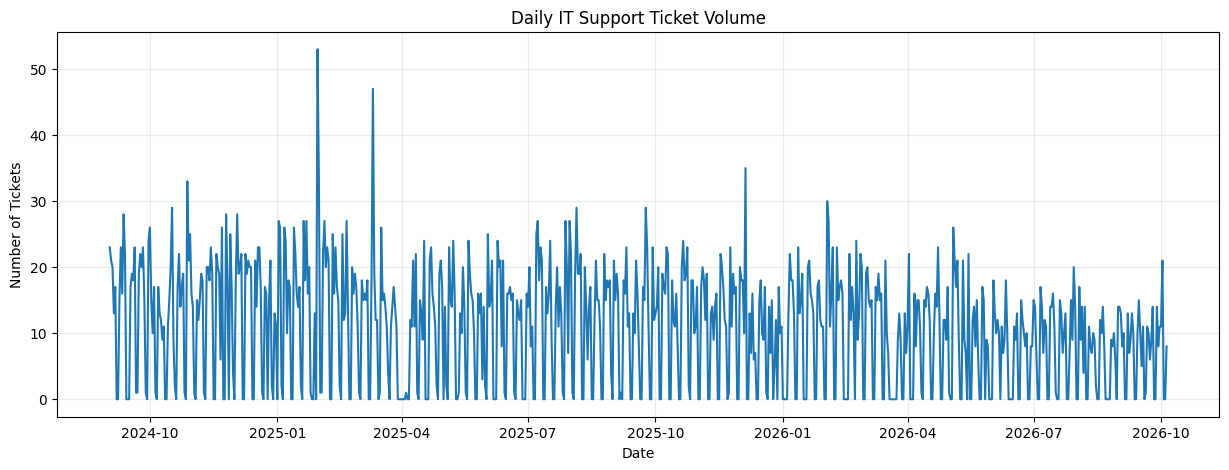

In [14]:
plt.figure(figsize=(15,5))
plt.plot(daily.index, daily["tickets"])
plt.title("Daily IT Support Ticket Volume")
plt.xlabel("Date")
plt.ylabel("Number of Tickets")
plt.grid(alpha=0.25)
plt.show()

## 5. Monthly Trend

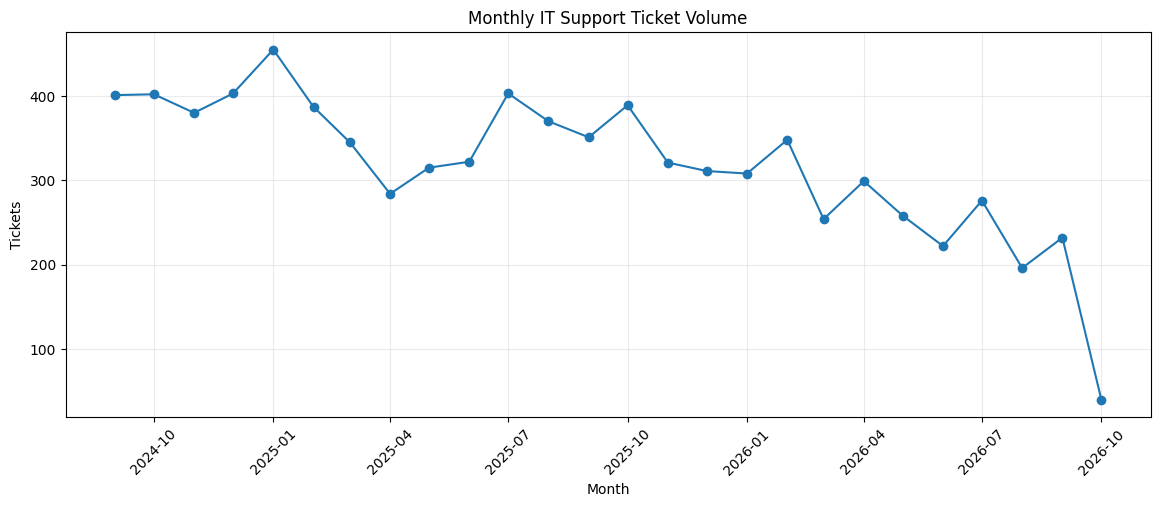

,tickets
Created At,
2024-09-01,401
2024-10-01,402
2024-11-01,380
2024-12-01,403
2025-01-01,455
2025-02-01,387
2025-03-01,345
2025-04-01,284
2025-05-01,315


In [15]:
monthly = daily["tickets"].resample("MS").sum()

plt.figure(figsize=(14,5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly IT Support Ticket Volume")
plt.xlabel("Month")
plt.ylabel("Tickets")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.show()

display(monthly.to_frame("tickets"))

## 6. Day-of-Week Pattern

,mean,median,sum
weekday,,,
Monday,16.518182,17.0,1817
Tuesday,15.366972,15.0,1675
Wednesday,14.100917,15.0,1537
Thursday,15.119266,15.0,1648
Friday,13.743119,14.0,1498
Saturday,0.844037,0.0,92
Sunday,0.045872,0.0,5


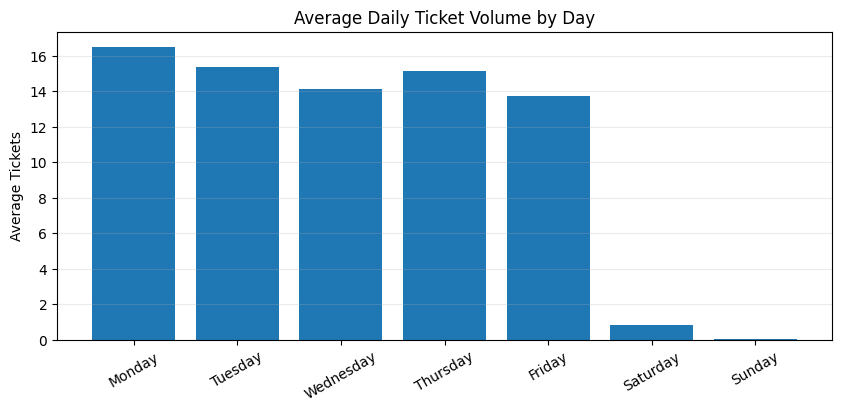

In [16]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday_summary = (
    daily.assign(weekday=daily.index.day_name())
         .groupby("weekday")["tickets"]
         .agg(["mean","median","sum"])
         .reindex(weekday_order)
)

display(weekday_summary)

plt.figure(figsize=(10,4))
plt.bar(weekday_summary.index, weekday_summary["mean"])
plt.title("Average Daily Ticket Volume by Day")
plt.ylabel("Average Tickets")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.25)
plt.show()

## 7. Forecasting Strategy

Karena ini adalah time series, data **tidak di-random split**.

Kita menggunakan:
- **Training:** seluruh data sebelum September 2026
- **Validation/Test:** September 2026
- **Final forecast:** setelah model terbaik dipilih, model dilatih ulang pada seluruh data aktual sampai tanggal terakhir.

Model yang dibandingkan:
1. Naive — nilai terakhir
2. Seasonal Naive — nilai 7 hari sebelumnya
3. Holt-Winters Exponential Smoothing
4. Random Forest dengan lag features

Metrik:
- MAE
- RMSE
- MAPE

In [17]:
# Holdout: September 2026
test_start = pd.Timestamp("2026-09-01")
test_end = pd.Timestamp("2026-09-30")

train = daily.loc[daily.index < test_start, "tickets"].copy()
test = daily.loc[test_start:test_end, "tickets"].copy()

print("Train:", train.index.min(), "to", train.index.max(), "| n =", len(train))
print("Test :", test.index.min(), "to", test.index.max(), "| n =", len(test))

Train: 2024-09-02 00:00:00 to 2026-08-31 00:00:00 | n = 729
Test : 2026-09-01 00:00:00 to 2026-09-30 00:00:00 | n = 30


In [18]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred)
    }

## 8. Baseline 1 — Naive Forecast

In [19]:
naive_pred = np.repeat(train.iloc[-1], len(test))
naive_result = evaluate(test, naive_pred)

print(naive_result)

{'MAE': 6.333333333333333, 'RMSE': np.float64(8.099382692526634), 'MAPE': np.float64(99.39157460896591)}


## 9. Baseline 2 — Seasonal Naive (7-day seasonality)

In [20]:
seasonal_naive_pred = np.array([
    train.iloc[-7 + i % 7] for i in range(len(test))
])

seasonal_naive_result = evaluate(test, seasonal_naive_pred)
print(seasonal_naive_result)

{'MAE': 3.7, 'RMSE': np.float64(5.437523946307424), 'MAPE': np.float64(40.484829180481356)}


## 10. Model 1 — Holt-Winters

In [21]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
).fit(optimized=True)

hw_pred = hw_model.forecast(len(test))
hw_result = evaluate(test, hw_pred)

print(hw_result)

{'MAE': 2.1816245161748125, 'RMSE': np.float64(2.5932046510998497), 'MAPE': np.float64(38.50085055982445)}


## 11. Model 2 — Random Forest with Lag Features

In [22]:
def make_lag_features(series, lags=(1,2,3,7,14,21,28)):
    data = pd.DataFrame({"y": series.copy()})
    for lag in lags:
        data[f"lag_{lag}"] = data["y"].shift(lag)

    data["rolling_7"] = data["y"].shift(1).rolling(7).mean()
    data["rolling_14"] = data["y"].shift(1).rolling(14).mean()
    data["rolling_28"] = data["y"].shift(1).rolling(28).mean()

    data["dayofweek"] = data.index.dayofweek
    data["dayofmonth"] = data.index.day
    data["month"] = data.index.month

    return data.dropna()

train_features = make_lag_features(train)

X_train = train_features.drop(columns="y")
y_train = train_features["y"]

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Recursive forecasting
history = train.copy()
rf_preds = []

for date in test.index:
    temp = pd.DataFrame({"y": history})
    for lag in (1,2,3,7,14,21,28):
        temp[f"lag_{lag}"] = temp["y"].shift(lag)

    temp["rolling_7"] = temp["y"].shift(1).rolling(7).mean()
    temp["rolling_14"] = temp["y"].shift(1).rolling(14).mean()
    temp["rolling_28"] = temp["y"].shift(1).rolling(28).mean()

    row = pd.DataFrame(index=[date])
    row["lag_1"] = history.iloc[-1]
    row["lag_2"] = history.iloc[-2]
    row["lag_3"] = history.iloc[-3]
    row["lag_7"] = history.iloc[-7]
    row["lag_14"] = history.iloc[-14]
    row["lag_21"] = history.iloc[-21]
    row["lag_28"] = history.iloc[-28]
    row["rolling_7"] = history.iloc[-7:].mean()
    row["rolling_14"] = history.iloc[-14:].mean()
    row["rolling_28"] = history.iloc[-28:].mean()
    row["dayofweek"] = date.dayofweek
    row["dayofmonth"] = date.day
    row["month"] = date.month

    pred = max(0, rf.predict(row[X_train.columns])[0])
    rf_preds.append(pred)
    history.loc[date] = pred

rf_result = evaluate(test, rf_preds)
print(rf_result)

{'MAE': 1.9357773182874316, 'RMSE': np.float64(2.4859483379172307), 'MAPE': np.float64(26.645235373847235)}


## 12. Compare All Models

,Model,MAE,RMSE,MAPE
3,Random Forest Lag,1.935777,2.485948,26.645235
2,Holt-Winters,2.181625,2.593205,38.500851
1,Seasonal Naive (7D),3.700000,5.437524,40.484829
0,Naive,6.333333,8.099383,99.391575


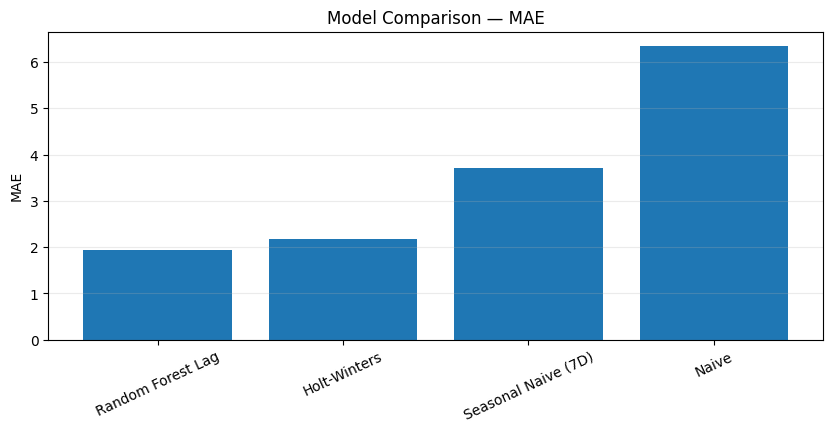

In [23]:
results = pd.DataFrame([
    {"Model":"Naive", **naive_result},
    {"Model":"Seasonal Naive (7D)", **seasonal_naive_result},
    {"Model":"Holt-Winters", **hw_result},
    {"Model":"Random Forest Lag", **rf_result}
]).sort_values("MAE")

display(results)

plt.figure(figsize=(10,4))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison — MAE")
plt.ylabel("MAE")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.25)
plt.show()

## 13. Actual vs Forecast on Holdout

,Actual,Naive,Seasonal_Naive,Holt_Winters,Random_Forest
2026-09-01,14,14,0,10.473187,10.065011
2026-09-02,13,14,9,10.172448,11.673078
2026-09-03,8,14,8,11.022598,10.559268
2026-09-04,10,14,10,9.331134,9.489183
2026-09-05,0,14,6,-1.214501,1.051032
2026-09-06,0,14,0,-2.214063,0.348467
2026-09-07,13,14,14,11.498707,10.213961
2026-09-08,7,14,0,10.411823,10.852824
2026-09-09,9,14,9,10.111084,10.395606
2026-09-10,13,14,8,10.961234,11.015929


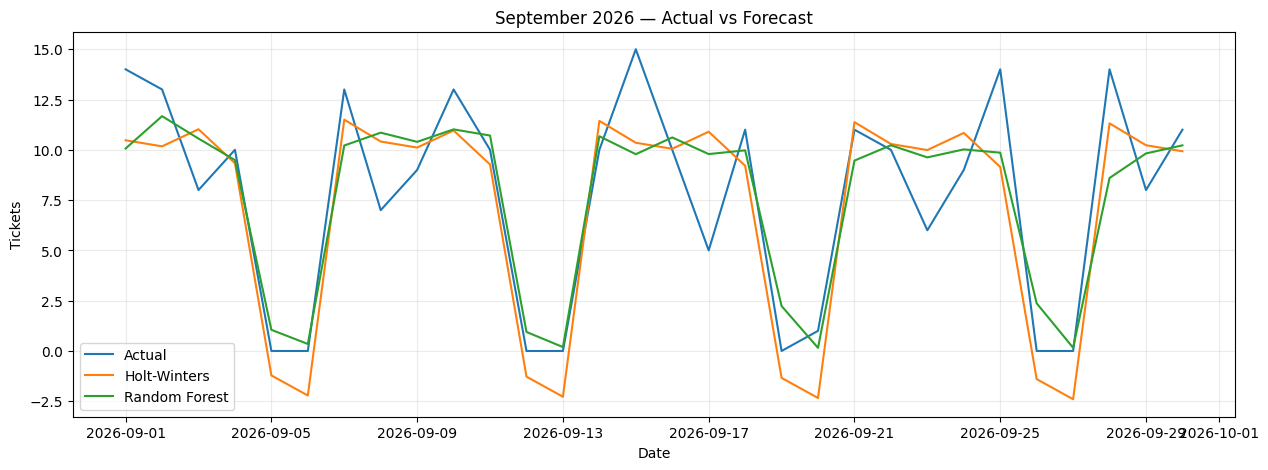

In [24]:
comparison = pd.DataFrame({
    "Actual": test,
    "Naive": naive_pred,
    "Seasonal_Naive": seasonal_naive_pred,
    "Holt_Winters": hw_pred,
    "Random_Forest": rf_preds
})

display(comparison)

plt.figure(figsize=(15,5))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, hw_pred, label="Holt-Winters")
plt.plot(test.index, rf_preds, label="Random Forest")
plt.title("September 2026 — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Tickets")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 14. Final Model & Future Forecast

In [25]:
# Pilih model dengan MAE terkecil
best_model = results.iloc[0]["Model"]
print("Best model:", best_model)

# Forecast 30 hari ke depan dari tanggal terakhir yang tersedia
forecast_horizon = 30

if best_model == "Holt-Winters":
    final_model = ExponentialSmoothing(
        daily["tickets"],
        trend="add",
        seasonal="add",
        seasonal_periods=7,
        initialization_method="estimated"
    ).fit(optimized=True)

    future_pred = final_model.forecast(forecast_horizon)

elif best_model == "Random Forest Lag":
    final_train = daily["tickets"].copy()
    final_features = make_lag_features(final_train)

    X_final = final_features.drop(columns="y")
    y_final = final_features["y"]

    final_rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    final_rf.fit(X_final, y_final)

    history = final_train.copy()
    preds = []

    future_dates = pd.date_range(
        history.index.max() + pd.Timedelta(days=1),
        periods=forecast_horizon,
        freq="D"
    )

    for date in future_dates:
        row = pd.DataFrame(index=[date])
        row["lag_1"] = history.iloc[-1]
        row["lag_2"] = history.iloc[-2]
        row["lag_3"] = history.iloc[-3]
        row["lag_7"] = history.iloc[-7]
        row["lag_14"] = history.iloc[-14]
        row["lag_21"] = history.iloc[-21]
        row["lag_28"] = history.iloc[-28]
        row["rolling_7"] = history.iloc[-7:].mean()
        row["rolling_14"] = history.iloc[-14:].mean()
        row["rolling_28"] = history.iloc[-28:].mean()
        row["dayofweek"] = date.dayofweek
        row["dayofmonth"] = date.day
        row["month"] = date.month

        pred = max(0, final_rf.predict(row[X_final.columns])[0])
        preds.append(pred)
        history.loc[date] = pred

    future_pred = pd.Series(preds, index=future_dates)

else:
    future_dates = pd.date_range(
        daily.index.max() + pd.Timedelta(days=1),
        periods=forecast_horizon,
        freq="D"
    )
    future_pred = pd.Series(
        [daily["tickets"].iloc[-1]] * forecast_horizon,
        index=future_dates
    )

forecast_df = pd.DataFrame({
    "date": future_pred.index,
    "forecast_tickets": np.round(future_pred.values, 1)
})

display(forecast_df)

Best model: Random Forest Lag


,date,forecast_tickets
0,2026-10-06,11.8
1,2026-10-07,10.1
2,2026-10-08,9.5
3,2026-10-09,9.7
4,2026-10-10,0.6
5,2026-10-11,0.0
6,2026-10-12,10.8
7,2026-10-13,9.7
8,2026-10-14,10.7
9,2026-10-15,10.7


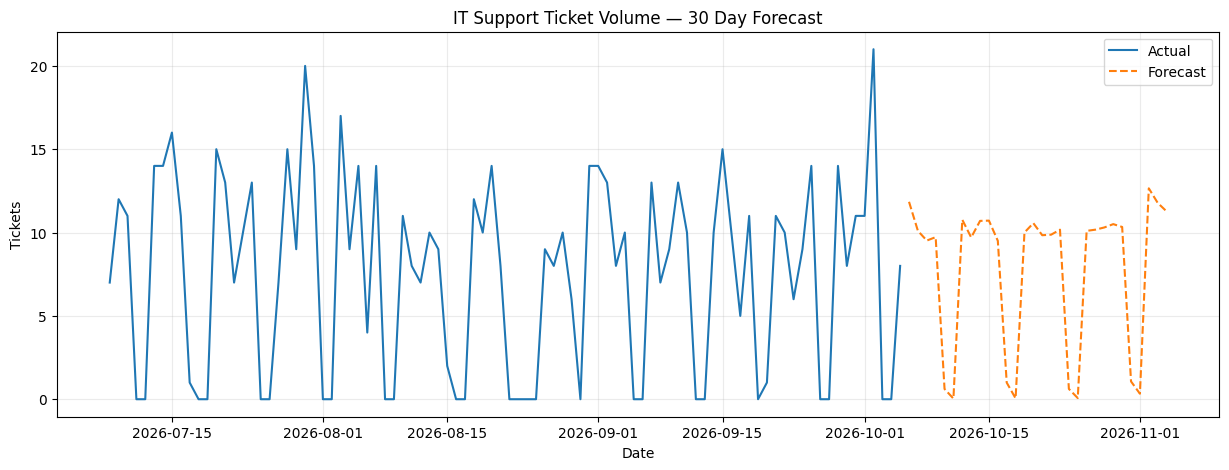

In [26]:
plt.figure(figsize=(15,5))
recent = daily["tickets"].tail(90)

plt.plot(recent.index, recent.values, label="Actual")
plt.plot(future_pred.index, future_pred.values, label="Forecast", linestyle="--")

plt.title("IT Support Ticket Volume — 30 Day Forecast")
plt.xlabel("Date")
plt.ylabel("Tickets")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 15. Business Interpretation

In [27]:
avg_forecast = future_pred.mean()
peak_forecast = future_pred.max()
peak_date = future_pred.idxmax()
total_forecast = future_pred.sum()

business_summary = pd.DataFrame({
    "Metric": [
        "Forecast horizon",
        "Expected total tickets",
        "Average tickets/day",
        "Peak forecast date",
        "Peak forecast tickets/day",
        "Best model"
    ],
    "Value": [
        f"{forecast_horizon} days",
        f"{total_forecast:.0f}",
        f"{avg_forecast:.1f}",
        peak_date.strftime("%Y-%m-%d"),
        f"{peak_forecast:.1f}",
        best_model
    ]
})

display(business_summary)

,Metric,Value
0,Forecast horizon,30 days
1,Expected total tickets,234
2,Average tickets/day,7.8
3,Peak forecast date,2026-11-02
4,Peak forecast tickets/day,12.7
5,Best model,Random Forest Lag


## 16. Key Business Insights

### Insight 1 — Demand Pattern
Volume tiket tidak tersebar merata sepanjang minggu. Hari kerja memiliki demand jauh lebih tinggi dibanding akhir pekan.

### Insight 2 — Workload Planning
Forecast 30 hari dapat digunakan sebagai dasar memperkirakan kapasitas agent, pembagian shift, dan kebutuhan backup.

### Insight 3 — Operational Risk
Forecast sebaiknya tidak hanya dilihat sebagai jumlah tiket, tetapi dikaitkan dengan SLA compliance dan overdue ticket. Periode dengan volume tinggi perlu diprioritaskan untuk monitoring SLA.

### Insight 4 — Data Limitation
Forecast hanya menggunakan volume tiket historis. Faktor eksternal seperti deployment sistem, maintenance, incident besar, hari libur, atau perubahan jumlah user belum dimasukkan sebagai explanatory variables.

## 17. Recommended Business Actions

1. **Capacity planning** — siapkan kapasitas support berdasarkan forecast demand.
2. **Peak-day staffing** — tambah coverage pada hari yang diprediksi memiliki volume tinggi.
3. **SLA monitoring** — kombinasikan forecast volume dengan historical SLA compliance.
4. **Proactive support** — gunakan kategori/product dengan volume tinggi sebagai prioritas knowledge base dan preventive maintenance.
5. **Forecast monitoring** — retrain model secara berkala ketika data baru tersedia.

## 18. Portfolio Storytelling

### Problem
Tim IT Support menerima ribuan tiket dengan pola demand yang berubah dari waktu ke waktu. Tanpa estimasi demand, staffing dan workload planning berisiko terlalu tinggi atau terlalu rendah.

### Approach
Saya menggabungkan data SLA Support 2024, 2025, dan 2026, membersihkan timestamp dan duplicate ticket, membentuk daily time series, menganalisis pola mingguan, kemudian membandingkan beberapa metode forecasting menggunakan time-based validation.

### Result
Model terbaik dipilih berdasarkan MAE/RMSE/MAPE pada September 2026 sebagai holdout period. Model tersebut kemudian digunakan untuk memproyeksikan demand 30 hari berikutnya.

### Business Impact
Forecast dapat membantu tim IT Support melakukan capacity planning, mengantisipasi peak workload, dan menghubungkan demand forecast dengan SLA monitoring.

### Tools
Python, Pandas, Matplotlib, Scikit-learn, Statsmodels, Google Colab.

## 19. Optional Extensions

Agar proyek semakin kuat untuk portofolio Data Science, proyek dapat dikembangkan menjadi:

- Forecast per **Product** (WMS, ERP, Hardware, Software, dll.)
- Forecast per **Section** (CORE, INFRA, ERP, NON CORE)
- Forecast **Overdue Ticket**
- Forecast dengan **holiday/calendar features**
- XGBoost/LightGBM dengan lag & calendar features
- Prophet sebagai benchmark
- Dashboard Power BI untuk actual vs forecast
- Alert ketika actual ticket volume melebihi forecast threshold

Project portfolio Data Analyst / Data Science menggunakan data SLA Support 2025–2026.

## Objective
Forecast jumlah tiket IT Support per hari untuk membantu:
- capacity planning,
- workload planning,
- staffing,
- SLA monitoring.

## Dataset
- SLA Support Oktober - Desember 2024
- SLA Support Full Year 2025
- SLA Support Full Year 2026

Periode 2026 bersifat year-to-date sehingga Oktober 2026 belum lengkap.

## Method
1. Data loading
2. Data cleaning
3. Daily time-series aggregation
4. EDA
5. Time-based train/test split
6. Baseline comparison
7. Holt-Winters
8. Random Forest dengan lag features
9. Model evaluation
10. 30-day future forecast
11. Business interpretation

## Evaluation
Metrics:
- MAE
- RMSE
- MAPE

September 2026 digunakan sebagai holdout period agar evaluasi tidak mengalami data leakage.

## Tools
Python, Pandas, Matplotlib, Scikit-learn, Statsmodels, Google Colab.

## Portfolio Title
**IT Support Ticket Volume Forecasting — Predicting Future Support Demand from SLA Data**

## Business Value
Forecast membantu tim support mengantisipasi demand, mengatur kapasitas, dan menghubungkan workload dengan SLA performance.

## Files
- `IT_Support_Ticket_Forecasting_Google_Colab.ipynb`
"""